# Best-current EnergyPlus 23.2 ↔ Python BRCM comparison

This notebook develops the workflow one stage at a time: run EnergyPlus, generate the BRCM thermal network, configure external heat-flux (EHF) models, map EnergyPlus columns to BRCM identifiers, compose the BuildingModel, simulate, and compare. The IDF defines the RC network but does not by itself define BRCM forcing trajectories.

In [1]:
from pathlib import Path
import re, shutil, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

REPO = Path.cwd().parents[1]
EPD = Path.cwd().parents[3] / '_phd' / 'Y3'
REPO = Path.cwd().parents[1]
EPD = Path.cwd().parents[3] / '2025'
sys.path[:0] = [str(REPO / 'src'), str(EPD / 'src')]
from ReIDF import IDFout, run_IDF, md_IDFdt
import brcm

CASE_NAME = '1ZoneUncontrolled1'
IDF = REPO / '_E+' / f'{CASE_NAME}.idf'
IDD = REPO / '_E+/idd/23.2/Energy+.idd'
EPW = EPD / 'src' / '_base/epw/ED-TMYx.2023.epw'
ENERGYPLUS = Path('/Applications/EnergyPlus-23-2-0/energyplus') if sys.platform == 'darwin' else Path('C:/EnergyPlusV23-2-0/EnergyPlus.exe')
WORK = REPO / 'pre_test/outputs/validation/eplus_23_2_minimal' / CASE_NAME
WORK.mkdir(parents=True, exist_ok=True)
TS_HRS = 0.25
PERIODS = {
    'January': ('2023-01-01', '2023-01-05'),
    'April': ('2023-04-01', '2023-04-05'),
    'July': ('2023-07-01', '2023-07-05'),
    'October': ('2023-10-01', '2023-10-05'),
}
START_DATE, END_DATE = PERIODS['April']  # Step-by-step worked example below.

## 1 — Run EnergyPlus and export forcing/validation variables

EnergyPlus is run first to provide a common weather period, gain signals, and validation trajectories. Some outputs become BRCM forcing inputs; others are diagnostics only. Surface temperatures must not drive the final independent comparison.

The disposable copy is changed to a weather-only run. `md_IDFdt()` sets the requested RunPeriod, while `SimulationControl` is changed from design-day-only to weather-file-only so sizing environments cannot be concatenated into the CSV.

In [2]:
working_idf = WORK / IDF.name
shutil.copy2(IDF, working_idf)
md_IDFdt(working_idf, start_date=START_DATE, end_date=END_DATE)

lines = working_idf.read_text(encoding='utf-8').splitlines(keepends=True)
start = next(i for i, line in enumerate(lines) if line.strip().casefold().startswith('simulationcontrol,'))
fields, index = [], start + 1
while index < len(lines):
    fields.append(index)
    if ';' in lines[index]: break
    index += 1
for position, value in ((3, 'No'), (4, 'Yes')):
    row = fields[position]
    lines[row] = re.sub(r'^(\s*)(?:Yes|No)(\s*[,;])', rf'\g<1>{value}\g<2>', lines[row], flags=re.I)
working_idf.write_text(''.join(lines), encoding='utf-8')

window_data = (ENERGYPLUS.parent / 'DataSets' / 'Window5DataFile.dat').resolve()
text = working_idf.read_text(encoding='utf-8').replace(r'..\datasets\Window5DataFile.dat', str(window_data))
working_idf.write_text(text, encoding='utf-8')
with working_idf.open('a', encoding='utf-8') as stream:
    stream.write(r'''
Output:Variable,*,Site Outdoor Air Drybulb Temperature,timestep;
Output:Variable,*,Site Ground Temperature,timestep;
Output:Variable,*,Site Sky Temperature,timestep;
Output:Variable,*,Site Direct Solar Radiation Rate per Area,timestep;
Output:Variable,*,Site Diffuse Solar Radiation Rate per Area,timestep;
Output:Variable,*,Zone Mean Air Temperature,timestep;
Output:Variable,*,Surface Inside Face Temperature,timestep;
Output:Variable,*,Surface Outside Face Temperature,timestep;
Output:Variable,*,Surface Outside Face Outdoor Air Drybulb Temperature,timestep;
Output:Variable,*,Surface Inside Face Convection Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Convection Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Net Thermal Radiation Heat Gain Rate,timestep;
Output:Variable,*,Surface Outside Face Thermal Radiation to Air Heat Transfer Rate,timestep;
Output:Variable,*,Surface Outside Face Incident Solar Radiation Rate per Area,timestep;
Output:Variable,*,Surface Outside Face Solar Radiation Heat Gain Rate,timestep;
Output:Variable,*,Surface Window Transmitted Solar Radiation Rate,timestep;
Output:Variable,*,Surface Window Net Heat Transfer Rate,timestep;
Output:Variable,*,Zone Windows Total Transmitted Solar Radiation Rate,timestep;
Output:Variable,*,Zone Total Internal Convective Heating Rate,timestep;
Output:Variable,*,Zone Total Internal Radiant Heating Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Outdoor Air Transfer Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Interzone Air Transfer Rate,timestep;
Output:Variable,*,Zone Air Heat Balance System Air Transfer Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Surface Convection Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Internal Convective Heat Gain Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Air Energy Storage Rate,timestep;
''')
IDFout(working_idf, ['CSV', 'MTR', 'Tabular', 'RDD'])
eplus_dir = Path(run_IDF(working_idf, EPW, ENERGYPLUS))
eplus = pd.read_csv(eplus_dir / 'eplusout.csv')
time_col = next(column for column in eplus if 'date/time' in column.casefold().replace(' ', ''))
print(f'EnergyPlus: {len(eplus)} samples, {len(eplus.columns) - 1} signals')

Simulation completed successfully.
Simulation Output Folder: C:\Users\s2589602\Downloads\2026\BRCMToolbox_adapted\pre_test\outputs\validation\eplus_23_2_minimal\1ZoneUncontrolled1\1ZoneUncontrolled1
EnergyPlus: 480 samples, 87 signals


## 2 — Generate the BRCM ThermalModel from the IDF

This stage creates only `dx/dt = A x + Bq q`. `A` is in s⁻¹, `Bq` is K/J, and `Xcap` is J/K. State and heat-flux ordering is given by the model identifiers. Ambient temperature, solar gains, internal gains, HVAC, and trajectories are not yet defined.

In [3]:
conversion = brcm.convert_idf_to_brcm_data(IDF, idd_path=IDD)
thermal_data = brcm.conversion_to_thermal_model_data(conversion)
thermal_model = brcm.generate_thermal_model(thermal_data)

## 3 — Configure the EHF models

All EHF constructors use `(thermal_data, thermal_model, identifier, source_file)`.

| EHF class | Generated signal | Expected units | Convention |
|---|---|---|---|
| `InternalGains` | `v_IG_<name>` | W/m² | multiplied by zone floor area |
| `BuildingHull` | `v_Tamb`, optional `v_Tgnd`, `v_solGlobFac_<name>` | °C and W/m² | ambient conduction, solar, windows and infiltration |
| `Radiators` | `u_rad_<name>` | W/m² | positive heating |
| `BEHeatfluxes` | `u_BEH_<name>_heat/cool` | W/m² | targets a one-based massive layer |
| `AHU` | identifier-prefixed mass flow/heating/cooling | kg/s, W, °C | mass-flow × temperature terms are bilinear |

This uncontrolled example uses `BuildingHull` and `InternalGains`. Window incident irradiance is an input; EnergyPlus transmitted-solar and net-window-heat columns remain validation signals. Opaque solar is unavailable here because the outdoor constructions are massless and the Python opaque-solar path requires a massive envelope state.

In [4]:
ehf_dir = WORK / 'ehf'
ehf_dir.mkdir(parents=True, exist_ok=True)
window_elements = [element for element in thermal_data.building_elements if element.window_identifier]
ep_window_by_parent = {window.parent_surface.casefold(): window for window in conversion.normalized_model.windows}
hull_rows = ['facade_solar_group;buildingelement_identifier;disturbance_identifier;absorptance;', 'window_solar_group;buildingelement_identifier;disturbance_identifier;control_identifier;secondary_gains_fraction;']
for element in window_elements:
    hull_rows.append(f';{element.identifier};{element.identifier};;1;')
hull_rows.append('infiltration_specification;zone_identifier;airchangerate;;;')
for zone in thermal_data.zones:
    hull_rows.append(f';{zone.identifier};0;;;')
hull_file = ehf_dir / 'building_hull.csv'
hull_file.write_text('\n'.join(hull_rows) + '\n', encoding='utf-8')
gains_file = ehf_dir / 'internal_gains.csv'
gains_file.write_text('zone_identifier;disturbance_identifier;\n' + ''.join(f'{zone.identifier};{zone.identifier};\n' for zone in thermal_data.zones), encoding='utf-8')
building_hull = brcm.BuildingHull(thermal_data, thermal_model, 'hull', hull_file)
internal_gains = brcm.InternalGains(thermal_data, thermal_model, 'gains', gains_file)
ehf_models = [building_hull, internal_gains]
[(model.EHF_identifier, model.identifiers.u, model.identifiers.v) for model in ehf_models]

[('hull', [], ['v_Tamb', 'v_solGlobFac_B0001']), ('gains', [], ['v_IG_Z0001'])]

In [5]:
def column_in(frame, variable, key=None):
    matches = [column for column in frame if variable.casefold() in column.casefold() and (key is None or f'{key}:{variable}'.casefold() in column.casefold())]
    if len(matches) != 1: raise KeyError(f'Expected one column for {key!r}/{variable!r}; found {matches}')
    return matches[0]

def prepare_weather_idf(path, start_date, end_date):
    shutil.copy2(IDF, path)
    md_IDFdt(path, start_date=start_date, end_date=end_date)
    lines = path.read_text(encoding='utf-8').splitlines(keepends=True)
    for object_name, changes in [('RunPeriod,', {3: str(pd.Timestamp(start_date).year), 6: str(pd.Timestamp(end_date).year)}), ('SimulationControl,', {3: 'No', 4: 'Yes'})]:
        start = next(i for i, line in enumerate(lines) if line.strip().casefold().startswith(object_name.casefold()))
        fields, index = [], start + 1
        while index < len(lines):
            fields.append(index)
            if ';' in lines[index]: break
            index += 1
        for position, value in changes.items():
            row = fields[position]
            delimiter = ',' if ',' in lines[row] else ';'
            suffix = lines[row][lines[row].find(delimiter):]
            indent = lines[row][:len(lines[row]) - len(lines[row].lstrip())]
            lines[row] = f'{indent}{value}{suffix}'
    path.write_text(''.join(lines), encoding='utf-8')
    window_data = (ENERGYPLUS.parent / 'DataSets' / 'Window5DataFile.dat').resolve()
    text = path.read_text(encoding='utf-8').replace(r'..\datasets\Window5DataFile.dat', str(window_data))
    requests = '\n'.join([
        'Output:Variable,*,Site Outdoor Air Drybulb Temperature,timestep;',
        'Output:Variable,*,Site Ground Temperature,timestep;',
        'Output:Variable,*,Site Sky Temperature,timestep;',
        'Output:Variable,*,Site Direct Solar Radiation Rate per Area,timestep;',
        'Output:Variable,*,Site Diffuse Solar Radiation Rate per Area,timestep;',
        'Output:Variable,*,Zone Mean Air Temperature,timestep;',
        'Output:Variable,*,Surface Inside Face Temperature,timestep;',
        'Output:Variable,*,Surface Outside Face Temperature,timestep;',
        'Output:Variable,*,Surface Outside Face Outdoor Air Drybulb Temperature,timestep;',
        'Output:Variable,*,Surface Outside Face Convection Heat Transfer Coefficient,timestep;',
        'Output:Variable,*,Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient,timestep;',
        'Output:Variable,*,Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient,timestep;',
        'Output:Variable,*,Surface Outside Face Net Thermal Radiation Heat Gain Rate,timestep;',
        'Output:Variable,*,Surface Outside Face Thermal Radiation to Air Heat Transfer Rate,timestep;',
        'Output:Variable,*,Surface Outside Face Incident Solar Radiation Rate per Area,timestep;',
        'Output:Variable,*,Surface Outside Face Solar Radiation Heat Gain Rate,timestep;',
        'Output:Variable,*,Surface Window Transmitted Solar Radiation Rate,timestep;',
        'Output:Variable,*,Surface Window Net Heat Transfer Rate,timestep;',
        'Output:Variable,*,Zone Windows Total Transmitted Solar Radiation Rate,timestep;',
        'Output:Variable,*,Zone Total Internal Convective Heating Rate,timestep;',
        'Output:Variable,*,Zone Total Internal Radiant Heating Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Surface Convection Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Internal Convective Heat Gain Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Outdoor Air Transfer Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Interzone Air Transfer Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance System Air Transfer Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Air Energy Storage Rate,timestep;',
    ])
    path.write_text(text + '\n' + requests + '\n', encoding='utf-8')
    IDFout(path, ['CSV', 'MTR', 'Tabular', 'RDD'])

def interval_end_datetimes(values, year):
    result = []
    for raw in values:
        month, day, hour, minute, second = map(int, re.fullmatch(r'\s*(\d{1,2})/(\d{1,2})\s+(\d{1,2}):(\d{2}):(\d{2})\s*', str(raw)).groups())
        result.append(pd.Timestamp(year=year, month=month, day=day) + pd.Timedelta(hours=hour, minutes=minute, seconds=second))
    return pd.DatetimeIndex(result)

seasonal_results = {}
for season, (start_date, end_date) in PERIODS.items():
    run_root = WORK / "seasonal" / season.casefold()
    run_root.mkdir(parents=True, exist_ok=True)
    seasonal_idf = run_root / IDF.name
    prepare_weather_idf(seasonal_idf, start_date, end_date)
    output_dir = Path(run_IDF(seasonal_idf, EPW, ENERGYPLUS))
    frame = pd.read_csv(output_dir / "eplusout.csv")
    time_column = next(column for column in frame if "date/time" in column.casefold().replace(" ", ""))
    times = interval_end_datetimes(frame[time_column], pd.Timestamp(start_date).year)
    zone = thermal_data.zones[0]
    ep_zone = frame[column_in(frame, "Zone Mean Air Temperature", zone.description)].to_numpy(float)
    outdoor = frame[column_in(frame, "Site Outdoor Air Drybulb Temperature")].to_numpy(float)
    seasonal_results[season] = dict(times=times, ep=ep_zone, outdoor=outdoor, start=start_date, end=end_date, zone=zone.description, frame=frame, output_dir=output_dir)
print("Prepared four weather periods for the single best-current model:", list(seasonal_results))


Simulation completed successfully.
Simulation Output Folder: C:\Users\s2589602\Downloads\2026\BRCMToolbox_adapted\pre_test\outputs\validation\eplus_23_2_minimal\1ZoneUncontrolled1\seasonal\january\1ZoneUncontrolled1
Simulation completed successfully.
Simulation Output Folder: C:\Users\s2589602\Downloads\2026\BRCMToolbox_adapted\pre_test\outputs\validation\eplus_23_2_minimal\1ZoneUncontrolled1\seasonal\april\1ZoneUncontrolled1
Simulation completed successfully.
Simulation Output Folder: C:\Users\s2589602\Downloads\2026\BRCMToolbox_adapted\pre_test\outputs\validation\eplus_23_2_minimal\1ZoneUncontrolled1\seasonal\july\1ZoneUncontrolled1
Simulation completed successfully.
Simulation Output Folder: C:\Users\s2589602\Downloads\2026\BRCMToolbox_adapted\pre_test\outputs\validation\eplus_23_2_minimal\1ZoneUncontrolled1\seasonal\october\1ZoneUncontrolled1
Prepared four weather periods for the single best-current model: ['January', 'April', 'July', 'October']


## 4 — Run the single best-current model for four seasons

This section applies only changes supported by the ablation notebook. It is not calibrated. EnergyPlus-equivalent transmitted window solar and exterior diagnostic outputs are used to test model equivalence, so this is not a fully independent BRCM prediction. All changes are notebook-local; the package implementation is not overwritten.

,Parameter,Value,Unit,Source
0,Window assembly U,3.798,W/m²K,EnergyPlus EIO FenestrationAssembly
1,Window assembly SHGC/g,0.684,-,EnergyPlus EIO FenestrationAssembly
2,Window gross area,10.000,m²,converted geometry


,State,Initialization,T0 [°C]
0,x_Z0001,direct EP zone-air temperature,6.871468
1,x_B0005_L1_s1_ADBZ0001,resistance-weighted EP surfaces (f=0.500),7.228406


Massless exterior elements receive no invented thermal states.


,EP surface,BRCM element,net area [m²],G_in [W/K],exterior representation
0,Zn001:Wall001,B0001,59.67728,24.519984,algebraic; no surface C
1,Zn001:Wall002,B0002,69.67728,28.628748,algebraic; no surface C
2,Zn001:Wall003,B0003,69.67728,28.628748,algebraic; no surface C
3,Zn001:Wall004,B0004,69.67728,28.628748,algebraic; no surface C
4,Zn001:Roof001,B0006,232.25760,41.615768,algebraic; no surface C


,Case,RMSE [K],CVRMSE [%],NMBE [%],MAE [K],Max absolute error [K],std(ΔT) [K/step],max |ΔT| [K/step],std(ΔT) ratio to EP,Accuracy rank,Roughness rank,Combined rank score,Overall rank
3,C3 — C1 + algebraic path / fixed exterior h,1.6741,15.7373,7.4280,1.1790,6.2852,0.1744,0.6258,1.3892,4.0,2.0,6.0,1
4,C4 — full best-current dynamic exterior,1.4686,13.8054,4.2329,1.1299,5.5168,0.2783,2.8365,2.2168,2.0,5.0,7.0,2
2,C2 — C1 + opaque solar / simplified exterior,1.6741,15.7373,7.4280,1.1790,6.2852,0.1744,0.6258,1.3892,6.0,2.0,8.0,3
1,C1 — corrected window + EP-equivalent transmit...,2.5166,23.6570,-17.7813,2.0388,4.6974,0.1100,0.4174,0.8767,8.0,1.0,9.0,4
0,C0 — converted baseline,2.7366,25.7250,-19.7941,2.2186,5.0429,0.0875,0.3144,0.6969,10.0,4.0,14.0,5


EnergyPlus roughness: std(ΔT)= 0.1255 K/step; max |ΔT|= 0.8458 K/step


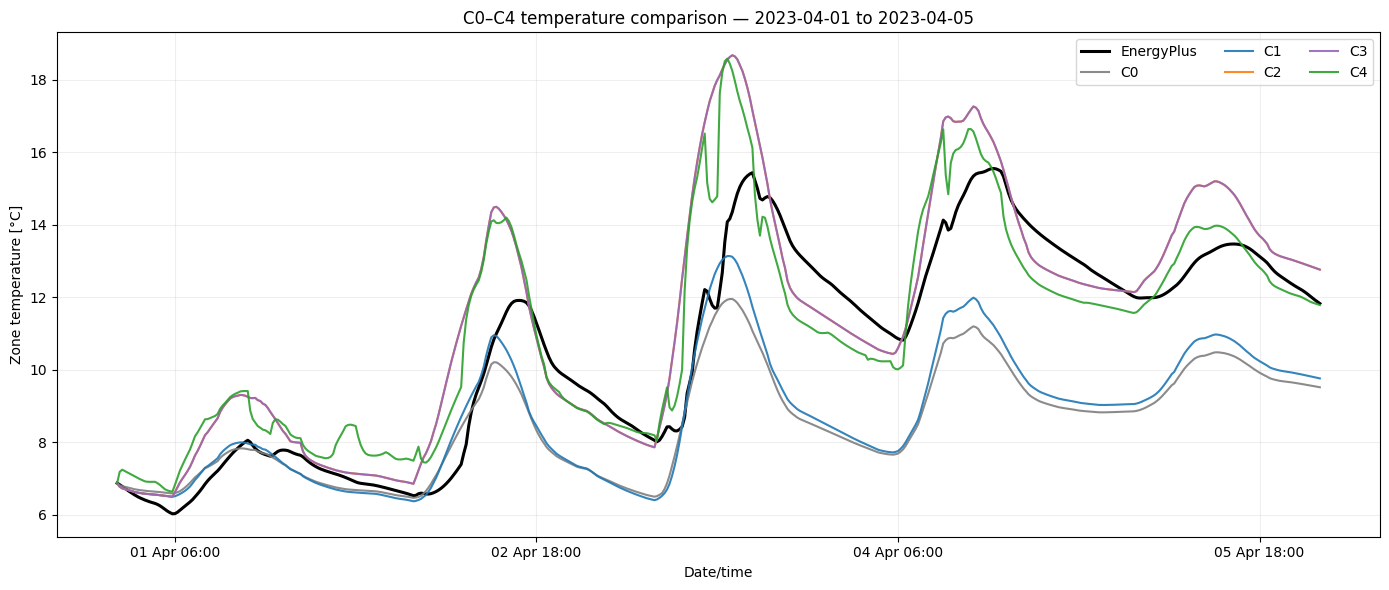

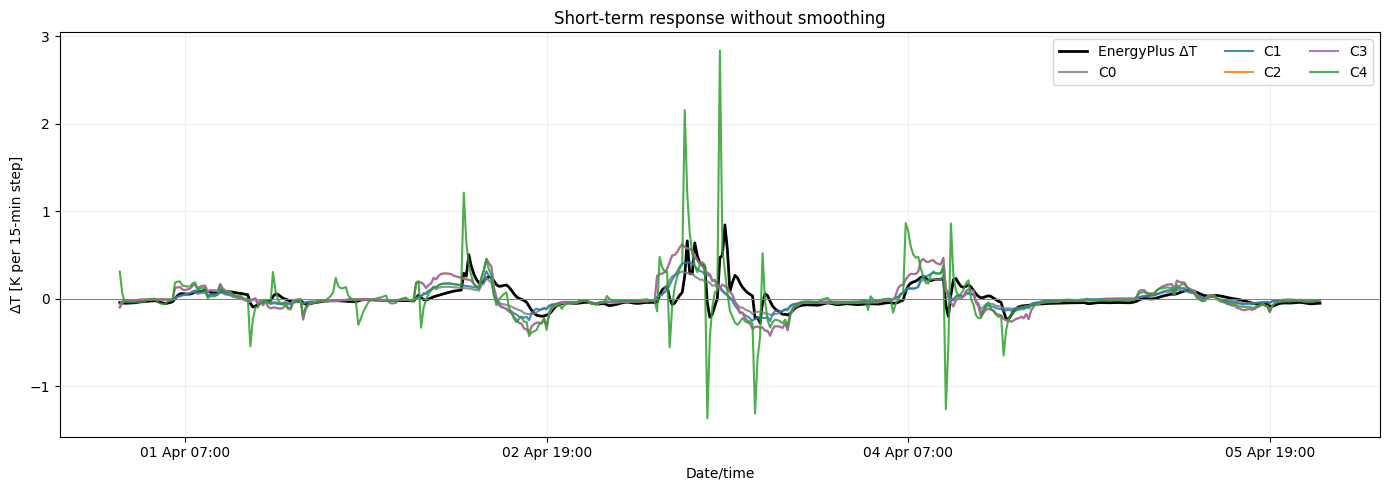

,Case,Accuracy rank,Roughness rank,Combined rank score,Overall rank
3,C3 — C1 + algebraic path / fixed exterior h,4.0,2.0,6.0,1
4,C4 — full best-current dynamic exterior,2.0,5.0,7.0,2
2,C2 — C1 + opaque solar / simplified exterior,6.0,2.0,8.0,3
1,C1 — corrected window + EP-equivalent transmit...,8.0,1.0,9.0,4
0,C0 — converted baseline,10.0,4.0,14.0,5


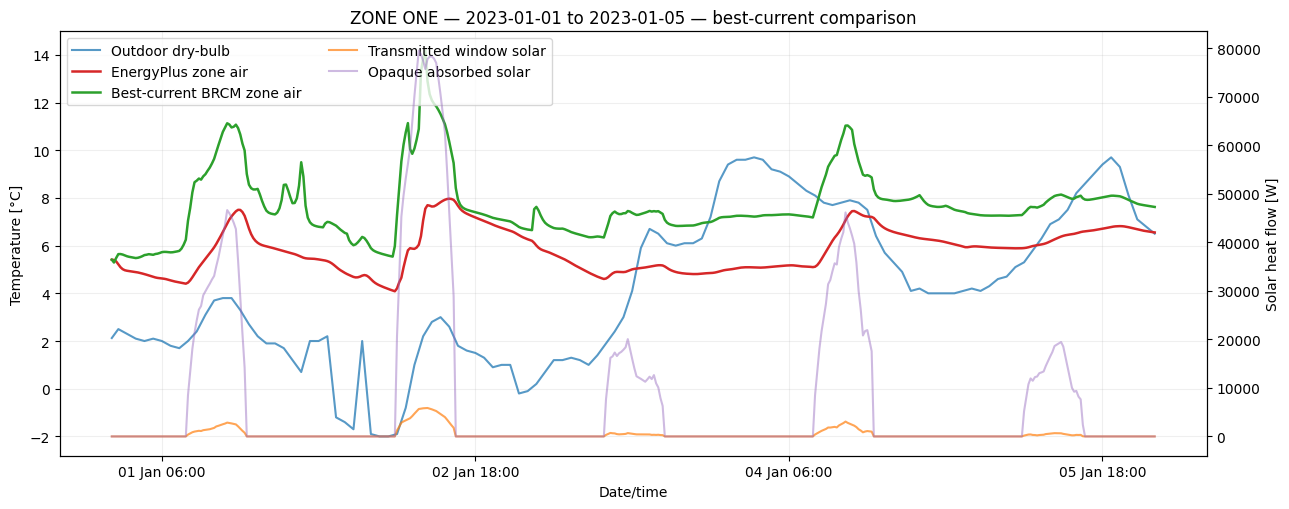

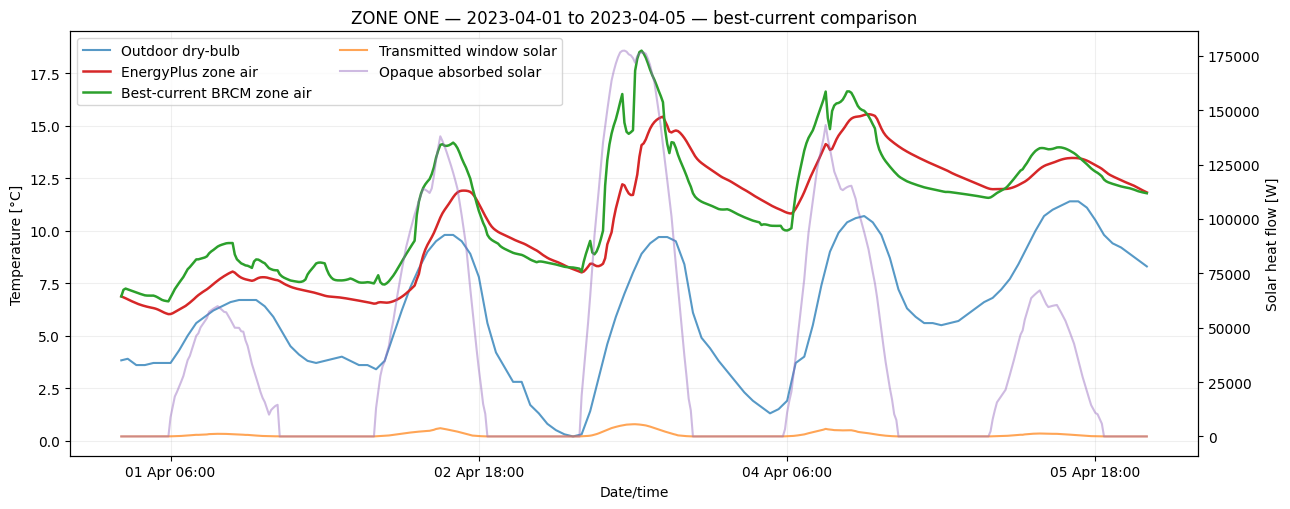

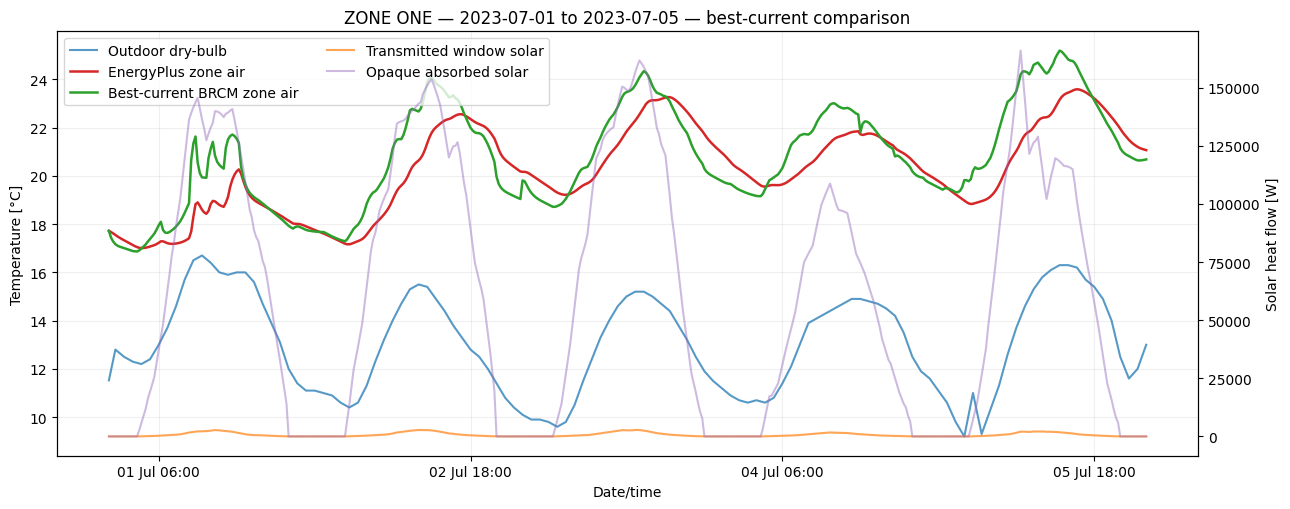

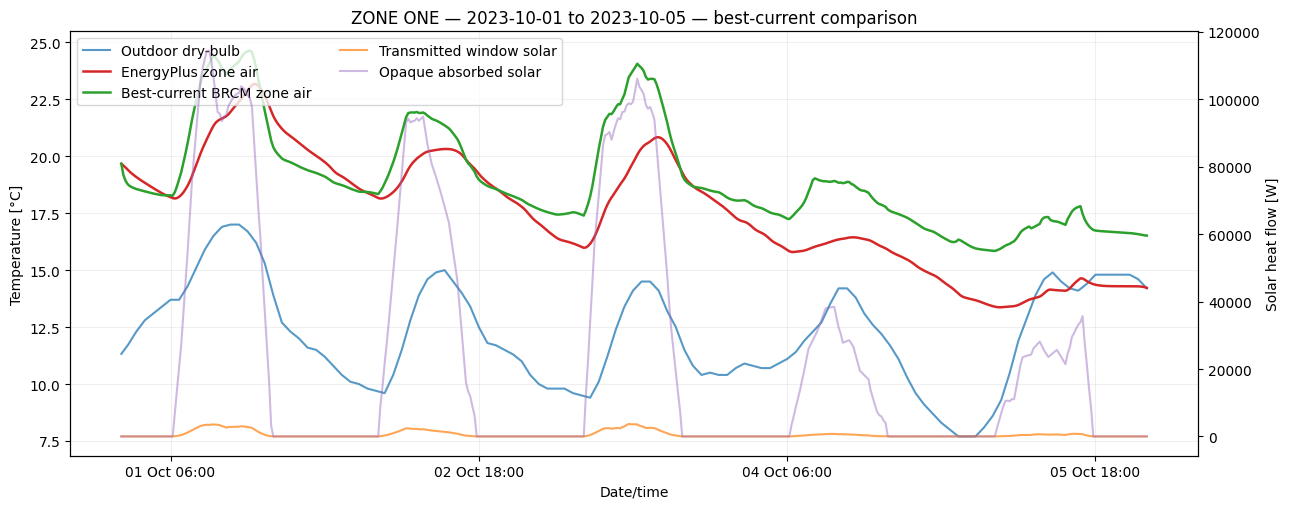

,Season,RMSE [K],CVRMSE [%],NMBE [%],MAE [K],Max absolute error [K]
0,January,2.133,36.783,31.980,1.855,6.899
1,April,1.469,13.805,4.233,1.130,5.517
2,July,1.182,5.839,2.472,0.933,3.038
3,October,1.927,10.988,8.042,1.602,4.095


,EnergyPlus signal,mean |W|,max |W|,nonzero fraction,Status
0,Zone Total Internal Convective Heating Rate,0.0,0.0,0.0,verified zero
1,Zone Total Internal Radiant Heating Rate,0.0,0.0,0.0,verified zero
2,Zone Air Heat Balance Outdoor Air Transfer Rate,0.0,0.0,0.0,verified zero
3,Zone Air Heat Balance Interzone Air Transfer Rate,0.0,0.0,0.0,verified zero
4,Zone Air Heat Balance System Air Transfer Rate,0.0,0.0,0.0,verified zero


Ground long-wave reference used: EnergyPlus Site Ground Temperature (available, but not confirmed as the effective exterior radiant reference).
Best-current is diagnostic-equivalent, not fully independent, because EP transmitted solar and exterior diagnostic terms are used.


In [6]:
import copy

best = seasonal_results['April']
best_frame = best['frame']; best_times = best['times']; best_ep = best['ep']; best_outdoor = best['outdoor']; best_zone = thermal_data.zones[0]
n_best = len(best_frame); zone_state = f'x_{best_zone.identifier}'; zone_q = f'q_{best_zone.identifier}'; zone_i = thermal_model.state_identifiers.index(zone_state); C_zone = thermal_model.Xcap[zone_i, zone_i]

# EnergyPlus FenestrationAssembly values include frame/divider effects in the closest lumped form supported by Python BRCM.
best_eio_lines = (best['output_dir'] / 'eplusout.eio').read_text(errors='replace').splitlines()
assembly_line = next(line for line in best_eio_lines if line.startswith('FenestrationAssembly,DOUBLECLEAR,'))
assembly_parts = [part.strip() for part in assembly_line.split(',')]
best_window_u = float(assembly_parts[4]); best_window_shgc = float(assembly_parts[5])
best_data = copy.deepcopy(thermal_data)
best_window_element = next(e for e in best_data.building_elements if e.window_identifier)
best_window = best_data.windows[best_data.get_window_idx_from_identifier(best_window_element.window_identifier)]
for parameter in best_data.parameters:
    if parameter.identifier == best_window.U_value: parameter.value = str(best_window_u)
    if parameter.identifier == best_window.SHGC: parameter.value = str(best_window_shgc)
best_window_area = best_data.eval_str(best_window.glass_area) + best_data.eval_str(best_window.frame_area)
best_parameter_table = pd.DataFrame([['Window assembly U',best_window_u,'W/m²K','EnergyPlus EIO FenestrationAssembly'],['Window assembly SHGC/g',best_window_shgc,'-','EnergyPlus EIO FenestrationAssembly'],['Window gross area',best_window_area,'m²','converted geometry']],columns=['Parameter','Value','Unit','Source'])
display(best_parameter_table)

best_hull = brcm.BuildingHull(best_data, thermal_model, 'best_current_hull', hull_file)
best_gains = brcm.InternalGains(best_data, thermal_model, 'best_current_gains', gains_file)
# Remove BRCM's calculated transmitted-solar term only; corrected assembly-U conduction remains.
best_hull_no_window_solar = copy.deepcopy(best_hull)
qi_local = best_hull_no_window_solar.identifiers.q.index(zone_q); vi_local = best_hull_no_window_solar.identifiers.v.index(f'v_solGlobFac_{best_window_element.identifier}')
best_hull_no_window_solar.Bq_v[qi_local,vi_local] -= best_window_shgc * best_window_area

class BestCurrentWindowSolar(brcm.EHFModelBaseClass):
    def __init__(self):
        super().__init__(best_data,thermal_model,'EnergyPlus-equivalent transmitted window solar',hull_file)
        self.identifiers.v=['v_EP_equivalent_window_transmitted_solar_W']; self._zeros(); self.Bq_v[self.identifiers.q.index(zone_q),0]=1.0
    def get_constraints_matrices(self,parameters): return self._empty_constraints()
    def get_cost_vector(self,parameters): return np.zeros((0,1))
best_window_solar_ehf=BestCurrentWindowSolar()
best_m1_model=brcm.BuildingModel(thermal_model,[best_hull_no_window_solar,best_gains,best_window_solar_ehf]); best_m1_model.discretize(TS_HRS)

# Defensible initialization: zone from EP; represented massive layers by resistance-weighted EP inside/outside temperatures.
best_x0=np.full((len(thermal_model.state_identifiers),1),float(best_ep[0])); initialization_rows=[]
construction_map={c.identifier:c for c in best_data.constructions}; material_map={m.identifier:m for m in best_data.materials}
for state_index,state_name in enumerate(thermal_model.state_identifiers):
    if state_name.startswith('x_Z'):
        initialization_rows.append([state_name,'direct EP zone-air temperature',best_x0[state_index,0]])
        continue
    match=re.match(r'x_(B\d{4})_L(\d+)_',state_name)
    if not match: continue
    element=next(e for e in best_data.building_elements if e.identifier==match.group(1)); surface=element.description.split(':',1)[1]; construction=construction_map[element.construction_identifier]
    resistances=[]
    for material_id,thickness_raw in zip(construction.material_identifiers,construction.thickness):
        material=material_map[material_id]; resistances.append(best_data.eval_str(material.R_value) if material.R_value else best_data.eval_str(thickness_raw)*best_data.eval_str(material.specific_thermal_resistance))
    layer0=int(match.group(2))-1; fraction=(sum(resistances[layer0+1:])+0.5*resistances[layer0])/sum(resistances)
    t_inside=best_frame[column_in(best_frame,'Surface Inside Face Temperature',surface)].iloc[0]; t_outside=best_frame[column_in(best_frame,'Surface Outside Face Temperature',surface)].iloc[0]
    best_x0[state_index,0]=t_inside+fraction*(t_outside-t_inside); initialization_rows.append([state_name,f'resistance-weighted EP surfaces (f={fraction:.3f})',best_x0[state_index,0]])
display(pd.DataFrame(initialization_rows,columns=['State','Initialization','T0 [°C]']))
print('Massless exterior elements receive no invented thermal states.')

best_window_name=next(name for name in best_frame.columns if 'Surface Window Transmitted Solar Radiation Rate' in name).split(':Surface Window',1)[0]
best_window_transmitted=best_frame[column_in(best_frame,'Surface Window Transmitted Solar Radiation Rate',best_window_name)].to_numpy(float)
def best_forcing(model):
    signals={}
    for name in model.identifiers.v:
        if name=='v_Tamb': signals[name]=best_outdoor
        elif name.startswith('v_IG_'):
            conv=best_frame[column_in(best_frame,'Zone Total Internal Convective Heating Rate',best_zone.description)].to_numpy(float); rad=best_frame[column_in(best_frame,'Zone Total Internal Radiant Heating Rate',best_zone.description)].to_numpy(float); signals[name]=(conv+rad)/best_data.eval_str(best_zone.area)
        elif name.startswith('v_solGlobFac_'): signals[name]=best_frame[column_in(best_frame,'Surface Outside Face Incident Solar Radiation Rate per Area',best_window_name)].to_numpy(float)
        elif name=='v_EP_equivalent_window_transmitted_solar_W': signals[name]=best_window_transmitted
        else: raise KeyError(f'No best-current forcing mapped for {name}')
    return np.vstack([signals[name][1:] for name in model.identifiers.v])

# Remove all five fixed ambient algebraic paths, then replace them with instantaneous exterior balances.
base_c=best_m1_model.continuous_time_model; A_algebraic=base_c.A.copy(); Bv_algebraic=base_c.Bv.copy(); amb_vi=best_m1_model.identifiers.v.index('v_Tamb'); v_best=best_forcing(best_m1_model)
ambient_elements=[e for e in best_data.building_elements if 'AMB' in (e.adjacent_A,e.adjacent_B)]; ambient_bcs=[bc for bc in thermal_model.boundary_conditions['ambient'] if zone_state in (bc.identifier_1,bc.identifier_2)]
surface_specs=[]
for element in ambient_elements:
    area=best_data.eval_str(element.area)
    if element.window_identifier: area-=best_window_area
    construction=construction_map[element.construction_identifier]; r_area=0.0
    for material_id,thickness_raw in zip(construction.material_identifiers,construction.thickness):
        material=material_map[material_id]; r_area+=best_data.eval_str(material.R_value) if material.R_value else best_data.eval_str(thickness_raw)*best_data.eval_str(material.specific_thermal_resistance)
    h_ext=best_data.eval_str(construction.conv_coeff_adjacent_A if element.adjacent_A=='AMB' else construction.conv_coeff_adjacent_B); h_int=best_data.eval_str(construction.conv_coeff_adjacent_B if element.adjacent_A=='AMB' else construction.conv_coeff_adjacent_A)
    G_in=1/(r_area/area+1/(h_int*area)); G_expected=1/(r_area/area+1/(h_int*area)+1/(h_ext*area)); bc=min(ambient_bcs,key=lambda candidate:abs(candidate.value-G_expected)); G_total=float(bc.value)
    A_algebraic[zone_i,zone_i]+=G_total/C_zone; Bv_algebraic[zone_i,amb_vi]-=G_total/C_zone
    surface_specs.append({'element':element,'surface':element.description.split(':',1)[1],'area':area,'G_in':G_in,'G_total':G_total,'h_ext':h_ext})
display(pd.DataFrame([[s['surface'],s['element'].identifier,s['area'],s['G_in'],'algebraic; no surface C'] for s in surface_specs],columns=['EP surface','BRCM element','net area [m²]','G_in [W/K]','exterior representation']))

sky_temperature=best_frame[column_in(best_frame,'Site Sky Temperature')].to_numpy(float); ground_temperature=best_frame[column_in(best_frame,'Site Ground Temperature')].to_numpy(float)
opaque_solar_total=np.zeros(n_best); reconstructed_lw_total=np.zeros(n_best); surface_diagnostics={}
for spec in surface_specs:
    surface,area=spec['surface'],spec['area']; ts_ep=best_frame[column_in(best_frame,'Surface Outside Face Temperature',surface)].to_numpy(float); hs=best_frame[column_in(best_frame,'Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient',surface)].to_numpy(float); hg=best_frame[column_in(best_frame,'Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient',surface)].to_numpy(float); qair=best_frame[column_in(best_frame,'Surface Outside Face Thermal Radiation to Air Heat Transfer Rate',surface)].to_numpy(float); qsolar=best_frame[column_in(best_frame,'Surface Outside Face Solar Radiation Heat Gain Rate',surface)].to_numpy(float)
    qsky=hs*area*(sky_temperature-ts_ep); qground=hg*area*(ground_temperature-ts_ep); qlw=qsky+qground+qair; opaque_solar_total+=qsolar; reconstructed_lw_total+=qlw; surface_diagnostics[surface]={'qsolar':qsolar,'qlw':qlw,'ts_ep':ts_ep}

best_state=best_x0[:,0].copy(); best_history=np.zeros((len(best_state),n_best)); best_history[:,0]=best_state; best_surface_temperatures=np.zeros((len(surface_specs),n_best))
for j,spec in enumerate(surface_specs): best_surface_temperatures[j,0]=surface_diagnostics[spec['surface']]['ts_ep'][0]
for k in range(n_best-1):
    A_step=A_algebraic.copy(); forcing= Bv_algebraic@v_best[:,k]; coefficients=[]
    for j,spec in enumerate(surface_specs):
        surface,area,G_in=spec['surface'],spec['area'],spec['G_in']; h=best_frame[column_in(best_frame,'Surface Outside Face Convection Heat Transfer Coefficient',surface)].iloc[k+1]; hA=h*area; tair=best_frame[column_in(best_frame,'Surface Outside Face Outdoor Air Drybulb Temperature',surface)].iloc[k+1]; qsolar=surface_diagnostics[surface]['qsolar'][k+1]; qlw=surface_diagnostics[surface]['qlw'][k+1]; denominator=hA+G_in; Geq=G_in*hA/denominator
        A_step[zone_i,zone_i]-=Geq/C_zone; forcing[zone_i]+=G_in*(hA*tair+qsolar+qlw)/denominator/C_zone; coefficients.append((hA,tair,qsolar,qlw,G_in,denominator))
    Ad,Bd=brcm.BuildingModel._zoh(A_step,forcing[:,None],TS_HRS*3600); best_state=Ad@best_state+Bd[:,0]; best_history[:,k+1]=best_state
    for j,(hA,tair,qsolar,qlw,G_in,denominator) in enumerate(coefficients): best_surface_temperatures[j,k+1]=(hA*tair+qsolar+qlw+G_in*best_state[zone_i])/denominator
best_current=best_history[zone_i]

# C0–C4 compromise study on the established April period. No smoothing or parameter fitting.
c0_model=brcm.BuildingModel(thermal_model,[building_hull,internal_gains]); c0_model.discretize(TS_HRS)
def forcing_for_converted_model(model):
    signals={}
    for name in model.identifiers.v:
        if name=='v_Tamb': signals[name]=best_outdoor
        elif name.startswith('v_IG_'):
            conv=best_frame[column_in(best_frame,'Zone Total Internal Convective Heating Rate',best_zone.description)].to_numpy(float); rad=best_frame[column_in(best_frame,'Zone Total Internal Radiant Heating Rate',best_zone.description)].to_numpy(float); signals[name]=(conv+rad)/best_data.eval_str(best_zone.area)
        elif name.startswith('v_solGlobFac_'): signals[name]=best_frame[column_in(best_frame,'Surface Outside Face Incident Solar Radiation Rate per Area',best_window_name)].to_numpy(float)
    return np.vstack([signals[name][1:] for name in model.identifiers.v])
C0=brcm.simulate_building_model(c0_model,best_x0,np.zeros((len(c0_model.identifiers.u),n_best-1)),forcing_for_converted_model(c0_model)).X_full[zone_i]
C1=brcm.simulate_building_model(best_m1_model,best_x0,np.zeros((len(best_m1_model.identifiers.u),n_best-1)),best_forcing(best_m1_model)).X_full[zone_i]

def simulate_time_varying_zone(A_reference,Bv_reference,V,extra_source):
    state=best_x0[:,0].copy(); history=np.zeros((len(state),n_best)); history[:,0]=state
    for k in range(n_best-1):
        forcing=Bv_reference@V[:,k]; forcing[zone_i]+=extra_source(k,state); Ad,Bd=brcm.BuildingModel._zoh(A_reference,forcing[:,None],TS_HRS*3600); state=Ad@state+Bd[:,0]; history[:,k+1]=state
    return history[zone_i]
def c2_solair_source(k,state):
    return sum(spec['G_total']/(spec['h_ext']*spec['area'])*surface_diagnostics[spec['surface']]['qsolar'][k+1]/C_zone for spec in surface_specs)
C2=simulate_time_varying_zone(base_c.A,base_c.Bv,v_best,c2_solair_source)

def simulate_c3_fixed_exterior():
    state=best_x0[:,0].copy(); history=np.zeros((len(state),n_best)); history[:,0]=state
    for k in range(n_best-1):
        A=A_algebraic.copy(); forcing=Bv_algebraic@v_best[:,k]
        for spec in surface_specs:
            surface,area,G,h=spec['surface'],spec['area'],spec['G_in'],spec['h_ext']; hA=h*area; denominator=hA+G; tair=best_outdoor[k+1]; qsolar=surface_diagnostics[surface]['qsolar'][k+1]; A[zone_i,zone_i]-=(G*hA/denominator)/C_zone; forcing[zone_i]+=G*(hA*tair+qsolar)/denominator/C_zone
        Ad,Bd=brcm.BuildingModel._zoh(A,forcing[:,None],TS_HRS*3600); state=Ad@state+Bd[:,0]; history[:,k+1]=state
    return history[zone_i]
C3=simulate_c3_fixed_exterior(); C4=best_current
compromise_cases={'C0 — converted baseline':C0,'C1 — corrected window + EP-equivalent transmitted solar':C1,'C2 — C1 + opaque solar / simplified exterior':C2,'C3 — C1 + algebraic path / fixed exterior h':C3,'C4 — full best-current dynamic exterior':C4}

ep_delta=np.diff(best_ep); compromise_rows=[]
for case,trajectory in compromise_cases.items():
    residual=trajectory-best_ep; delta=np.diff(trajectory); mean_ep=float(np.mean(best_ep)); rmse=float(np.sqrt(np.mean(residual**2))); compromise_rows.append([case,rmse,100*rmse/mean_ep,100*float(np.mean(residual))/mean_ep,float(np.mean(np.abs(residual))),float(np.max(np.abs(residual))),float(np.std(delta)),float(np.max(np.abs(delta))),float(np.std(delta)/np.std(ep_delta))])
compromise_table=pd.DataFrame(compromise_rows,columns=['Case','RMSE [K]','CVRMSE [%]','NMBE [%]','MAE [K]','Max absolute error [K]','std(ΔT) [K/step]','max |ΔT| [K/step]','std(ΔT) ratio to EP'])
compromise_table['Accuracy rank']=compromise_table['RMSE [K]'].rank(method='min')+compromise_table['NMBE [%]'].abs().rank(method='min'); compromise_table['Roughness rank']=np.abs(np.log(compromise_table['std(ΔT) ratio to EP'])).rank(method='min'); compromise_table['Combined rank score']=compromise_table['Accuracy rank']+compromise_table['Roughness rank']; compromise_table['Overall rank']=compromise_table['Combined rank score'].rank(method='min').astype(int)
display(compromise_table.sort_values('Overall rank').round(4))
print('EnergyPlus roughness: std(ΔT)=',round(float(np.std(ep_delta)),4),'K/step; max |ΔT|=',round(float(np.max(np.abs(ep_delta))),4),'K/step')

fig,axis=plt.subplots(figsize=(14,6)); axis.plot(best_times,best_ep,color='black',linewidth=2.2,label='EnergyPlus'); colors=['tab:gray','tab:blue','tab:orange','tab:purple','tab:green'];
for (case,trajectory),color in zip(compromise_cases.items(),colors): axis.plot(best_times,trajectory,label=case.split(' — ')[0],color=color,alpha=.9)
axis.set_ylabel('Zone temperature [°C]'); axis.set_xlabel('Date/time'); axis.grid(alpha=.2); axis.legend(ncol=3); axis.xaxis.set_major_locator(mdates.HourLocator(interval=36)); axis.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); axis.set_title(f'C0–C4 temperature comparison — {best["start"]} to {best["end"]}'); fig.tight_layout(); plt.show()
fig,axis=plt.subplots(figsize=(14,5)); delta_times=best_times[1:]; axis.plot(delta_times,ep_delta,color='black',linewidth=2,label='EnergyPlus ΔT');
for (case,trajectory),color in zip(compromise_cases.items(),colors): axis.plot(delta_times,np.diff(trajectory),label=case.split(' — ')[0],color=color,alpha=.85)
axis.axhline(0,color='grey',linewidth=.7); axis.set_ylabel('ΔT [K per 15-min step]'); axis.set_xlabel('Date/time'); axis.grid(alpha=.2); axis.legend(ncol=3); axis.xaxis.set_major_locator(mdates.HourLocator(interval=36)); axis.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); axis.set_title('Short-term response without smoothing'); fig.tight_layout(); plt.show()
display(compromise_table[['Case','Accuracy rank','Roughness rank','Combined rank score','Overall rank']].sort_values('Overall rank'))

def simulate_best_period(period):
    frame,ep,outdoor=period['frame'],period['ep'],period['outdoor']; n=len(frame); x0=np.full((len(thermal_model.state_identifiers),1),float(ep[0]))
    for state_index,state_name in enumerate(thermal_model.state_identifiers):
        match=re.match(r'x_(B\d{4})_L(\d+)_',state_name)
        if not match: continue
        element=next(e for e in best_data.building_elements if e.identifier==match.group(1)); surface=element.description.split(':',1)[1]; construction=construction_map[element.construction_identifier]; resistances=[]
        for material_id,thickness_raw in zip(construction.material_identifiers,construction.thickness):
            material=material_map[material_id]; resistances.append(best_data.eval_str(material.R_value) if material.R_value else best_data.eval_str(thickness_raw)*best_data.eval_str(material.specific_thermal_resistance))
        layer0=int(match.group(2))-1; fraction=(sum(resistances[layer0+1:])+0.5*resistances[layer0])/sum(resistances); tin=frame[column_in(frame,'Surface Inside Face Temperature',surface)].iloc[0]; tout=frame[column_in(frame,'Surface Outside Face Temperature',surface)].iloc[0]; x0[state_index,0]=tin+fraction*(tout-tin)
    window_name=next(c for c in frame if 'Surface Window Transmitted Solar Radiation Rate' in c).split(':Surface Window',1)[0]; window_solar=frame[column_in(frame,'Surface Window Transmitted Solar Radiation Rate',window_name)].to_numpy(float); signals={}
    for name in best_m1_model.identifiers.v:
        if name=='v_Tamb': signals[name]=outdoor
        elif name.startswith('v_IG_'): signals[name]=(frame[column_in(frame,'Zone Total Internal Convective Heating Rate',best_zone.description)].to_numpy(float)+frame[column_in(frame,'Zone Total Internal Radiant Heating Rate',best_zone.description)].to_numpy(float))/best_data.eval_str(best_zone.area)
        elif name.startswith('v_solGlobFac_'): signals[name]=frame[column_in(frame,'Surface Outside Face Incident Solar Radiation Rate per Area',window_name)].to_numpy(float)
        elif name=='v_EP_equivalent_window_transmitted_solar_W': signals[name]=window_solar
    V=np.vstack([signals[name][1:] for name in best_m1_model.identifiers.v]); sky=frame[column_in(frame,'Site Sky Temperature')].to_numpy(float); ground=frame[column_in(frame,'Site Ground Temperature')].to_numpy(float); terms={}; opaque=np.zeros(n)
    for spec in surface_specs:
        surface,area=spec['surface'],spec['area']; ts=frame[column_in(frame,'Surface Outside Face Temperature',surface)].to_numpy(float); hs=frame[column_in(frame,'Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient',surface)].to_numpy(float); hg=frame[column_in(frame,'Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient',surface)].to_numpy(float); qair=frame[column_in(frame,'Surface Outside Face Thermal Radiation to Air Heat Transfer Rate',surface)].to_numpy(float); qsolar=frame[column_in(frame,'Surface Outside Face Solar Radiation Heat Gain Rate',surface)].to_numpy(float); terms[surface]=(qsolar,hs*area*(sky-ts)+hg*area*(ground-ts)+qair); opaque+=qsolar
    state=x0[:,0].copy(); history=np.zeros((len(state),n)); history[:,0]=state
    for k in range(n-1):
        A=A_algebraic.copy(); forcing=Bv_algebraic@V[:,k]
        for spec in surface_specs:
            surface,area,G=spec['surface'],spec['area'],spec['G_in']; hA=frame[column_in(frame,'Surface Outside Face Convection Heat Transfer Coefficient',surface)].iloc[k+1]*area; tair=frame[column_in(frame,'Surface Outside Face Outdoor Air Drybulb Temperature',surface)].iloc[k+1]; qsolar,qlw=terms[surface]; denominator=hA+G; A[zone_i,zone_i]-=(G*hA/denominator)/C_zone; forcing[zone_i]+=G*(hA*tair+qsolar[k+1]+qlw[k+1])/denominator/C_zone
        Ad,Bd=brcm.BuildingModel._zoh(A,forcing[:,None],TS_HRS*3600); state=Ad@state+Bd[:,0]; history[:,k+1]=state
    return dict(**period,brcm=history[zone_i],window_solar=window_solar,opaque_solar=opaque)

best_seasons={season:simulate_best_period(period) for season,period in seasonal_results.items()}
season_rows=[]
for season,result in best_seasons.items():
    error=result['brcm']-result['ep']; mean_ep=float(np.mean(result['ep'])); rmse=float(np.sqrt(np.mean(error**2))); season_rows.append([season,rmse,100*rmse/mean_ep,100*float(np.mean(error))/mean_ep,float(np.mean(np.abs(error))),float(np.max(np.abs(error)))])
    fig,left=plt.subplots(figsize=(13,5.2)); left.plot(result['times'],result['outdoor'],color='tab:blue',alpha=.75,label='Outdoor dry-bulb'); left.plot(result['times'],result['ep'],color='tab:red',linewidth=1.8,label='EnergyPlus zone air'); left.plot(result['times'],result['brcm'],color='tab:green',linewidth=1.8,label='Best-current BRCM zone air'); left.set_ylabel('Temperature [°C]'); left.set_xlabel('Date/time'); left.grid(alpha=.2); right=left.twinx(); right.plot(result['times'],result['window_solar'],color='tab:orange',alpha=.7,label='Transmitted window solar'); right.plot(result['times'],result['opaque_solar'],color='tab:purple',alpha=.45,label='Opaque absorbed solar'); right.set_ylabel('Solar heat flow [W]'); h1,l1=left.get_legend_handles_labels(); h2,l2=right.get_legend_handles_labels(); left.legend(h1+h2,l1+l2,loc='upper left',ncol=2); left.xaxis.set_major_locator(mdates.HourLocator(interval=36)); left.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); left.set_title(f"{result['zone']} — {result['start']} to {result['end']} — best-current comparison"); fig.tight_layout(); plt.show()
seasonal_best_metrics=pd.DataFrame(season_rows,columns=['Season','RMSE [K]','CVRMSE [%]','NMBE [%]','MAE [K]','Max absolute error [K]']); display(seasonal_best_metrics.round(3))

# Compact zero-load audit.
zero_variables=['Zone Total Internal Convective Heating Rate','Zone Total Internal Radiant Heating Rate','Zone Air Heat Balance Outdoor Air Transfer Rate','Zone Air Heat Balance Interzone Air Transfer Rate','Zone Air Heat Balance System Air Transfer Rate']
zero_rows=[]
for variable in zero_variables:
    values=best_frame[column_in(best_frame,variable,best_zone.description)].to_numpy(float); zero_rows.append([variable,np.mean(np.abs(values)),np.max(np.abs(values)),np.mean(np.abs(values)>1e-9),'verified zero' if np.max(np.abs(values))<1e-6 else 'nonzero'])
zero_audit=pd.DataFrame(zero_rows,columns=['EnergyPlus signal','mean |W|','max |W|','nonzero fraction','Status']); display(zero_audit)


print('Ground long-wave reference used: EnergyPlus Site Ground Temperature (available, but not confirmed as the effective exterior radiant reference).')
print('Best-current is diagnostic-equivalent, not fully independent, because EP transmitted solar and exterior diagnostic terms are used.')


## What is included in the best-current model

Included:

- Corrected EnergyPlus FenestrationAssembly window U-value and SHGC/g-value. Frame/divider effects are represented only through that supported lumped assembly pair.
- **EnergyPlus-equivalent transmitted window solar**, explicitly labelled as diagnostic-equivalence forcing rather than an independent prediction.
- Corrected exterior heat-flow injection pathway for all five massless exterior elements.
- Algebraic massless exterior-surface balances, with no invented exterior capacitance or state.
- Dynamic exterior convection, opaque absorbed solar, and reconstructed sky/ground/air long-wave applied at each exterior balance.
- Verified zero internal gains, outdoor-air transfer, interzone transfer, and system-air transfer for this case.
- Direct EP zone-air initialization and resistance-weighted initialization for defensibly mapped massive construction states.

Not resolved:

- The exact EnergyPlus effective ground radiant reference temperature. `Site Ground Temperature` is used because it is available, but it does not fully reconcile wall radiation. No hidden temperature is inferred or fitted.
- Exact EnergyPlus exterior convection/radiation formulation.
- Possible differences in internal RC state placement.
- Window-model simplifications beyond the lumped supported U/SHGC representation.
- Exact MATLAB parity for this EnergyPlus 23.2 case.

All best-current changes are notebook-local. No package behavior is silently overwritten and no parameters are calibrated.

## C0–C4 compromise result

The comparison uses the same April timestamps and initial states for every case. Ranking is the unweighted sum of ordinal RMSE rank, absolute-NMBE rank, and roughness-deviation rank. No output is smoothed.

| Case | RMSE [K] | CVRMSE [%] | NMBE [%] | MAE [K] | Max error [K] | std(ΔT) [K/step] | max abs(ΔT) [K/step] | Roughness ratio to EP | Overall rank |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| C0 — converted baseline | 2.7366 | 25.7250 | -19.7941 | 2.2186 | 5.0429 | 0.0875 | 0.3144 | 0.6969 | 5 |
| C1 — corrected window and EP-equivalent transmitted solar | 2.5166 | 23.6570 | -17.7813 | 2.0388 | 4.6974 | 0.1100 | 0.4174 | 0.8767 | 3 |
| C2 — C1 plus opaque solar with simplified exterior treatment | 1.6741 | 15.7373 | 7.4280 | 1.1790 | 6.2852 | 0.1744 | 0.6258 | 1.3892 | 1 |
| C3 — algebraic pathway with fixed exterior coefficient | 1.6741 | 15.7373 | 7.4280 | 1.1790 | 6.2852 | 0.1744 | 0.6258 | 1.3892 | 3 (tie) |
| C4 — full dynamic exterior forcing | 1.4686 | 13.8054 | 4.2329 | 1.1299 | 5.5168 | 0.2783 | 2.8365 | 2.2168 | 2 |

EnergyPlus has `std(ΔT) = 0.1255 K/step` and `max |ΔT| = 0.8458 K/step`. C4's detailed time-varying exterior convection and reconstructed long-wave forcing produce the excess roughness and largest short-term jumps. C2 is the preferred compromise: it captures opaque solar and corrected window physics while retaining the simplified BRCM exterior boundary. C2 and C3 are numerically equivalent here because the fixed-coefficient algebraic massless balance reduces to the same steady sol-air pathway.

Corrected window U/SHGC and EnergyPlus-equivalent transmitted solar should be retained: C1 improves both accuracy and roughness relative to C0. Opaque absorbed solar should also be retained because it provides the main accuracy improvement in C2. Full dynamic convection/long-wave forcing should be simplified for the compromise model unless a future independent exterior-boundary formulation can reproduce EnergyPlus without the observed over-response.